<a href="https://colab.research.google.com/github/Lalepragati/ML/blob/main/2Copy_of_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install -U scikit-learn

 A decision tree is a popular supervised machine learning algorithm used for both classification and regression tasks. It works with categorical as well as continuous output variables and is widely used due to its simplicity, interpretability and strong performance on structured data.

 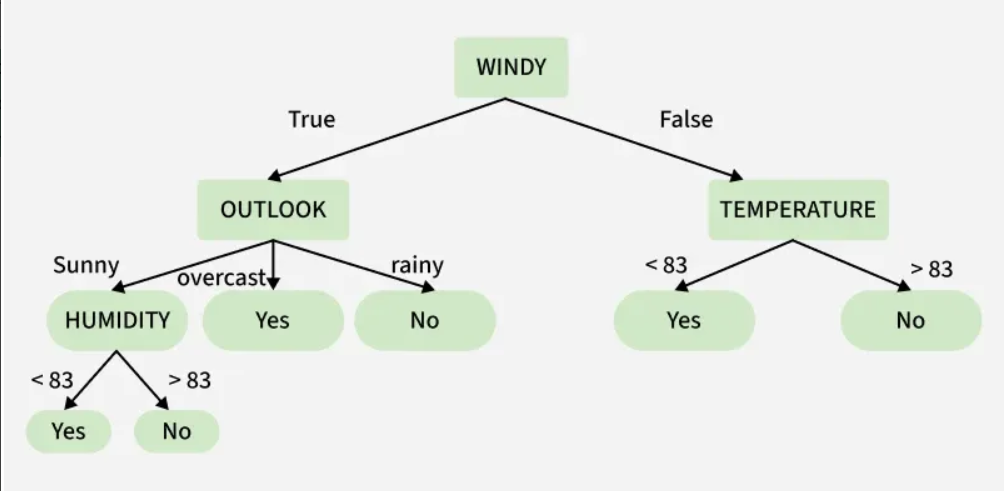

In the above figure, a decision tree is a flowchart-like structure with a root node (WINDY), internal nodes (OUTLOOK, TEMPERATURE) for attribute tests and leaf nodes for final decisions. The branches show the possible outcomes of each test. A Decision Tree follows a tree-like structure where:

Nodes represent decisions or feature tests
Branches represent outcomes of those decisions
Leaf nodes represent final predictions or class labels
The tree is constructed by recursively splitting the dataset based on the feature that provides the maximum information gain or minimum impurity.

How Decision Trees Work
Decision Trees work by selecting the best attribute at each step to split the data. This selection is based on statistical metrics that measure data impurity or uncertainty.

Start with the full dataset as the root node.
Select the best feature using a splitting criterion.
Split the dataset into subsets.
Repeat the process recursively until stopping conditions are met.
Assign class labels at leaf nodes.
Splitting Criteria in Decision Trees
Decision Trees select the best attributes for splits using metrics like Gini Index, Entropy and Information Gain helping decide the root and internal nodes. Entropy measures dataset impurity, guiding the tree to choose splits that reduce uncertainty.

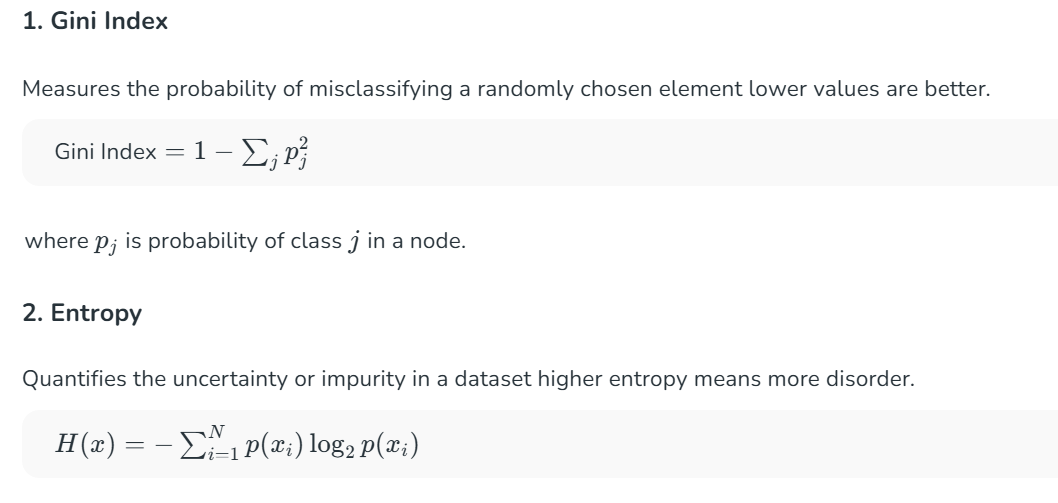


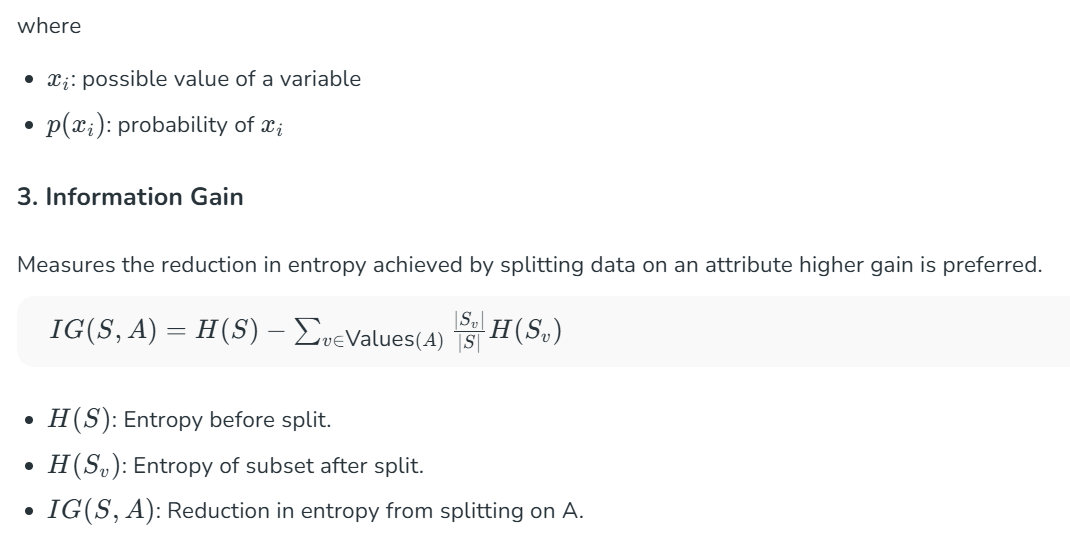

Dataset Length:  150
Dataset Shape:  (150, 5)
Dataset Head:     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
Training using Gini
Predicted Values:  ['virginica' 'setosa' 'virginica' 'setosa' 'virginica' 'virginica'
 'setosa' 'setosa' 'virginica' 'setosa' 'setosa' 'virginica' 'setosa'
 'setosa' 'virginica' 'versicolor' 'versicolor' 'virginica' 'virginica'
 'virginica' 'virginica' 'setosa' 'virginica' 'setosa' 'versicolor'
 'virginica' 'versicolor' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'v

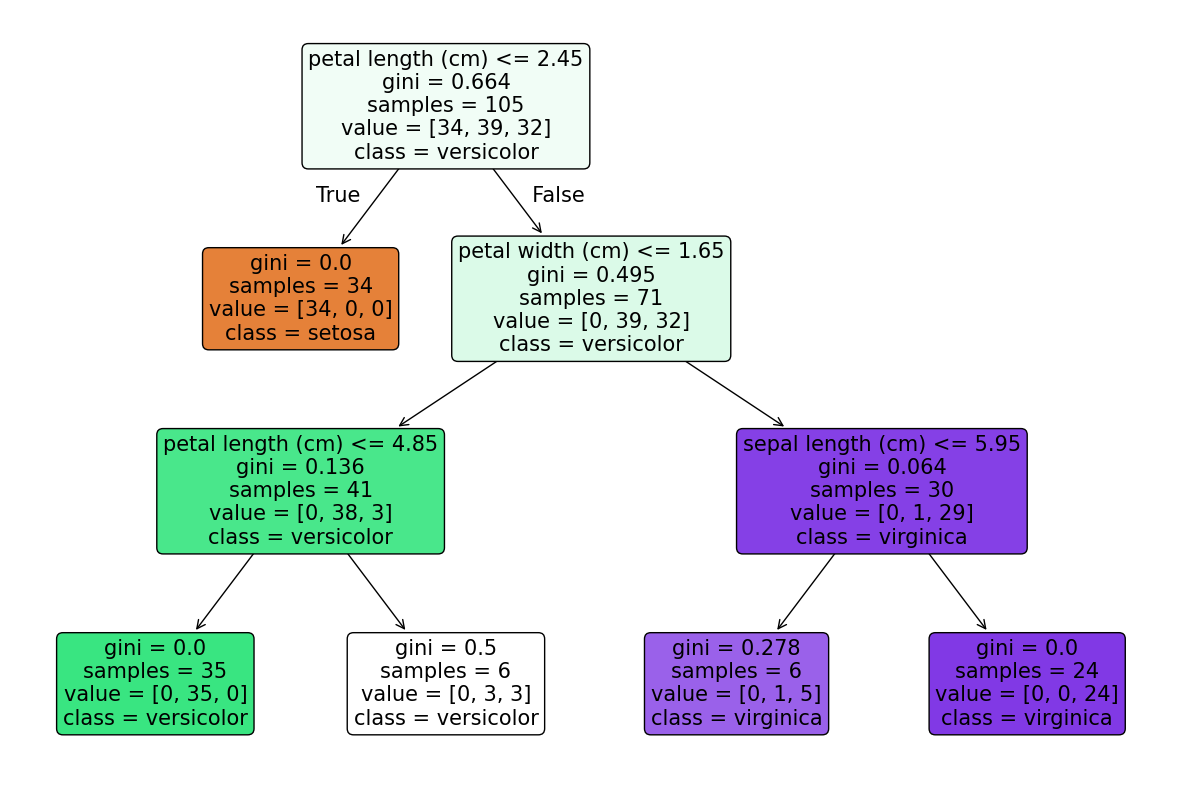

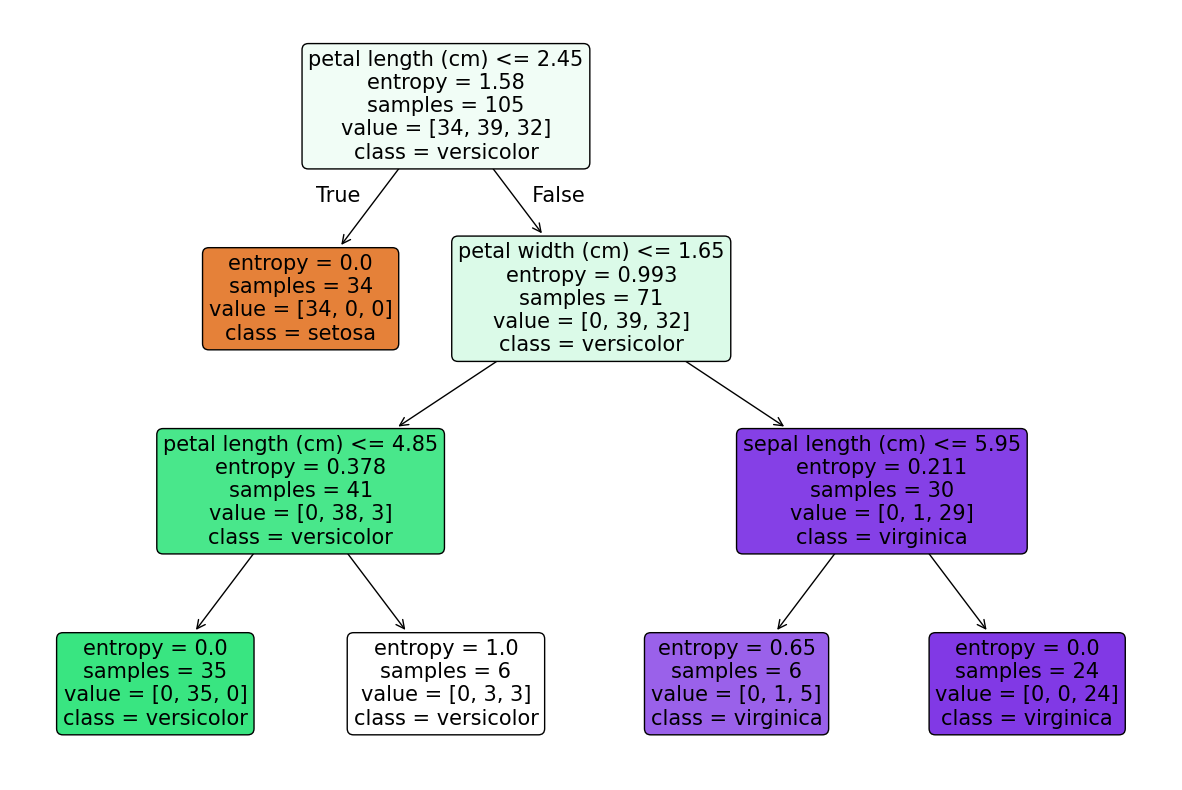

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris # Import load_iris
import matplotlib.pyplot as plt


def importdata():
    # Using the Iris dataset directly from sklearn.datasets for stability.
    iris = load_iris()
    iris_data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    iris_data['species'] = iris.target_names[iris.target]

    print("Dataset Length: ", len(iris_data))
    print("Dataset Shape: ", iris_data.shape)
    print("Dataset Head: ", iris_data.head())
    return iris_data


def splitdataset(data):
    # X contains features (all columns except 'species') and Y contains the class label ('species')
    X = data.drop('species', axis=1).values
    Y = data['species'].values
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.3, random_state=100
    )
    return X, Y, X_train, X_test, Y_train, Y_test


def train_using_gini(X_train, Y_train):
    clf_gini = DecisionTreeClassifier(
        criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5
    )
    clf_gini.fit(X_train, Y_train)
    return clf_gini


def train_using_entropy(X_train, Y_train):
    clf_entropy = DecisionTreeClassifier(
        criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5
    )
    clf_entropy.fit(X_train, Y_train)
    return clf_entropy


def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values: ", y_pred)
    return y_pred


def cal_accuracy(Y_test, y_pred):
    print("Confusion Matrix: ", confusion_matrix(Y_test, y_pred))
    print("Accuracy: ", accuracy_score(Y_test, y_pred) * 100)
    print("Classification Report: ", classification_report(Y_test, y_pred))


def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(
        clf_object,
        filled=True,
        feature_names=feature_names,
        class_names=class_names,
        rounded=True,
    )
    plt.show()


if __name__ == "__main__":
    data = importdata()
    X, Y, X_train, X_test, Y_train, Y_test = splitdataset(data)

    # Feature names for the Iris dataset from sklearn
    iris_feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
    # Class names for the Iris dataset from sklearn
    iris_class_names = ['setosa', 'versicolor', 'virginica']

    print("Training using Gini")
    clf_gini = train_using_gini(X_train, Y_train)
    y_pred_gini = prediction(X_test, clf_gini)
    cal_accuracy(Y_test, y_pred_gini)

    print("Training using Entropy")
    clf_entropy = train_using_entropy(X_train, Y_train)
    y_pred_entropy = prediction(X_test, clf_entropy)
    cal_accuracy(Y_test, y_pred_entropy)

    plot_decision_tree(clf_gini, iris_feature_names, iris_class_names)
    plot_decision_tree(clf_entropy, iris_feature_names, iris_class_names)

# New Section

## Potential Questions from an External Examiner:

### Theoretical Understanding of Decision Trees

1.  **Question:** What is a Decision Tree Classifier, and how does it work conceptually?
    *   **Answer:** A Decision Tree Classifier is a supervised machine learning algorithm used for classification tasks. It works by creating a tree-like model of decisions, where each internal node represents a 'test' on an attribute (feature), each branch represents the outcome of the test, and each leaf node represents a class label (decision). The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

2.  **Question:** Explain the difference between Gini Impurity and Entropy as splitting criteria in Decision Trees.
    *   **Answer:** Both Gini Impurity and Entropy are measures used to quantify the 'impurity' or 'disorder' of a set of samples. The algorithm uses these to decide which feature and split point provide the most 'information gain' (reduction in impurity) to make a decision.
        *   **Gini Impurity:** Measures how often a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset. A Gini impurity of 0 means all samples belong to a single class (pure node).
        *   **Entropy:** Originating from information theory, Entropy measures the average level of 'information' or 'uncertainty' in a set of data. A higher entropy indicates greater disorder, and an entropy of 0 means perfect purity. The algorithm aims to minimize entropy.
        *   **Key Difference:** While both aim for purity, Gini is slightly faster to compute as it doesn't involve logarithms, whereas Entropy might lead to more balanced trees.

3.  **Question:** What is information gain, and why is it important in Decision Tree construction?
    *   **Answer:** Information gain is the reduction in entropy (or Gini impurity) achieved by splitting a dataset on a particular feature. It quantifies how much 'uncertainty' about the class label is removed by knowing the value of a feature. The Decision Tree algorithm iteratively selects the feature that yields the highest information gain at each step to create the best possible split, aiming to make child nodes as pure as possible.

4.  **Question:** What are `max_depth` and `min_samples_leaf`? Why are they used, and what happens if they are not set correctly?
    *   **Answer:** These are hyperparameters used to control the complexity of the decision tree and prevent overfitting.
        *   **`max_depth`:** Limits the maximum depth of the tree. A deeper tree can model more complex relationships but is more prone to overfitting (memorizing the training data).
        *   **`min_samples_leaf`:** Specifies the minimum number of samples required to be at a leaf node. If a split results in a leaf node with fewer samples than this threshold, the split is disallowed. This helps smooth the model and reduce the impact of outliers.
        *   **Incorrect Settings:** If `max_depth` is too large or `min_samples_leaf` is too small, the tree can become overly complex and overfit the training data, leading to poor generalization on new data. Conversely, if they are too restrictive, the tree might be too simple (underfit), failing to capture the underlying patterns in the data.

### Code Implementation and Data Specifics

5.  **Question:** Why did you choose the Iris dataset for this demonstration?
    *   **Answer:** The Iris dataset is a classic and widely used dataset for classification tasks. It's readily available in `sklearn.datasets`, which makes it convenient and reliable for demonstrations like this. It has a manageable number of features (4) and classes (3), making it easy to understand, visualize, and interpret the decision tree models. It's a good starting point for explaining fundamental classification concepts.

6.  **Question:** Explain the purpose of `random_state` in your `train_test_split` and `DecisionTreeClassifier` calls.
    *   **Answer:** `random_state` is used to ensure reproducibility. In `train_test_split`, it fixes the random seed used for shuffling the data before splitting, meaning the same data points will always end up in the training and testing sets. In `DecisionTreeClassifier`, it controls the random processes (e.g., when breaking ties in feature selection) within the algorithm. By setting `random_state` to a fixed integer (like `100`), we guarantee that the experiment yields identical results every time it's run, which is crucial for consistent evaluation and debugging.

7.  **Question:** How does `splitdataset()` prepare the data for the Decision Tree models?
    *   **Answer:** The `splitdataset()` function first separates the features (`X`) from the target variable (`Y`). It then uses `sklearn.model_selection.train_test_split` to divide `X` and `Y` into training and testing sets. The `test_size=0.3` parameter means 30% of the data will be used for testing, and the remaining 70% for training. `random_state=100` ensures that this split is consistent across runs.

8.  **Question:** What do the `iris_feature_names` and `iris_class_names` lists represent, and why are they passed to `plot_decision_tree`?
    *   **Answer:**
        *   `iris_feature_names`: This list contains descriptive names for each of the input features in the Iris dataset (e.g., 'sepal length (cm)', 'petal width (cm)').
        *   `iris_class_names`: This list contains the names of the different target classes in the Iris dataset (e.g., 'setosa', 'versicolor', 'virginica').
        *   **Purpose in `plot_decision_tree`:** When passed to `plot_tree`, these lists make the generated decision tree plots much more interpretable. Instead of showing generic feature indices (like X[0]) and cryptic class labels, the plot displays human-readable names, making it easier to understand the decision rules the tree has learned.

### Model Evaluation

9.  **Question:** What does the `cal_accuracy()` function report, and what do those metrics mean?
    *   **Answer:** The `cal_accuracy()` function reports three key evaluation metrics:
        *   **Confusion Matrix:** A table that summarizes the performance of a classification model. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. It shows true positives, true negatives, false positives, and false negatives.
        *   **Accuracy Score:** The proportion of correctly classified instances out of the total instances. It's a general measure of how well the model performed overall.
        *   **Classification Report:** Provides a more detailed breakdown of performance per class, including:
            *   **Precision:** The proportion of true positive predictions among all positive predictions for a given class. It answers: